In [ ]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# 1. Force uninstall the old version completely
# !pip uninstall pyNanoMatBuilder -y

# 2. Install the new version with flags that bypass all caches and force a refresh
# !pip install --index-url https://test.pypi.org/simple/ pyNanoMatBuilder==0.9.0 --no-cache-dir --no-deps

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

pyNanoMatBuilder: parallelism set to 4 threads.



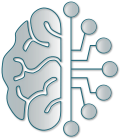

**Environment initialized:** Tuesday 09 June 2026, 17:47:57 on localhost.localdomain  
<span style='color: #007a7a; font-weight: bold;'>[OK] Parallel computing ENABLED (4 threads)</span>

pyNMB.__version__='0.15.1'


In [1]:
# # development purpose only. Comment these 2 lines on Google Colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.set_threads(4)
pyNMB.init()
%matplotlib inline
print(f"{pyNMB.__version__=}")

from pyNanoMatBuilder import utils as pyNMBu
import pyNanoMatBuilder as pyNMB

# Tutorials

## Evaluating relevant sizes to fit an experimental SAXS signal

### Context and workflow

<div class="intro">

A SAXS spectrum measured on a nanoparticle sample is never the signal of a single, perfectly monodisperse object. It is the weighted sum of contributions from particles of different sizes, distributed according to a size distribution (Gaussian, Schulz, etc.).
The goal of this section is to identify which discrete sizes are most relevant to reproduce and interpret an experimental SAXS spectrum, as a first step toward a full polydispersity-aware simulation. The overall workflow is:

1. Identify some characteristic sizes from the experimental distribution
2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them
3. Compute individual SAXS spectra for each structure, then sum them with the appropriate weights to reproduce the experimental spectrum

In this example, we work with **silver icosahedra** from the study of xxx et al. From SAXS experiments, after volumetric correction between spheres and icosahedra, the following parameters can be inferred:

- *&mu;*(exp) = 2.60 nm
- %PD = 11%

The size distribution is modeled here with a Schulz distribution, which is better suited than a Gaussian for SAXS/SANS experiments as it accounts for the natural asymmetry of nanoparticle size distributions (skewed toward larger sizes).
</div>

### Step 1. Identify some characteristic sizes from the experimental distribution

<div class="intro">

**(a) Theoretical Schulz distribution from SAXS fit**

From the experimental parameters, we build the theoretical Schulz distribution and identify the characteristic sizes at μ ± nσ. These sizes will serve as references for the atomic structures to be built and simulated in the following steps. The table shows, for each characteristic size, its relative weight in the distribution. Sizes close to μ carry the highest weight, while those beyond ±3σ contribute very little and can generally be neglected.

The next step will be to identify which nOrder values in pyNanoMatBuilder produce structures whose geometry, after optimization, best matches these target diameters. If perfect, defect-free icosahedra do not land close enough to the target sizes, structures with incomplete outer shells (surface peeling) will be considered as intermediate sizes between two consecutive magic numbers.
</div>

In [ ]:
nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes, nd.representative_labels])

<div class="intro">

**(b) Convert the SAXS diameter to a core-to-core diameter**

The diameter measured by SAXS includes the electron density cloud around each surface atom. To compare it with the core-to-core dimensions produced by pyNanoMatBuilder, we subtract one atomic radius on each side:

$$D_\text{core}=D_\text{SAXS}−2×r_\text{Ag}$$

We first inspect the available atomic radii for silver:
</div>

In [ ]:
Ag = pyNMBu.print_atomic_radii("Ag")
print()
print(Ag.metallic_radius)
print(Ag.get_ionic_radii(charge=+1, coordination='VI'))

<div class="intro">

For metallic nanoparticles, the metallic radius is the most physically meaningful choice — it reflects the actual atomic size in a crystalline metallic environment, and is consistent with the nearest-neighbor distance used internally by pyNanoMatBuilder (*Rnn* = 2 × *r*<sub>metallic</sub>).

We then rebuild the distribution using the corrected mean diameter — all sizes are now expressed as core-to-core distances, directly comparable to pyNanoMatBuilder output:
</div>

In [ ]:
mu_core = 2.60-2*Ag.metallic_radius/10

nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=mu_core, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes,nd.representative_labels])

<div class="rqE">

These corrected diameters are the actual target sizes to match with pyNanoMatBuilder structures in Step 2.
</div>

### Step 2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them

#### Find the nOrder value that yields an icosahedral NP with diameter close to *μ*

<div class="intro">
The first step is to identify which nOrder values produce icosahedra whose diameter, after geometry optimization, falls close to the target sizes identified in Step 1. This is done by a manual trial-and-error exploration: we build a few icosahedra with increasing nOrder, optimize their geometry, and compare their actual dimensions to *μ* − *σ*, *μ*, and *μ* + *σ*.
Magic-number icosahedra being discrete objects, there is no guarantee that a perfect, defect-free structure will land exactly on a target size. Between two consecutive nOrder values, intermediate sizes can be reached by peeling the outermost atomic layer, removing atoms with the lowest coordination number. This gives access to a continuous range of sizes between two magic numbers.
</div>

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

ico = pNP.regIco("Ag",
                 2.7,
                 5,
                 skipSymmetryAnalyzis=True,
                 noOutput=False
                )

pyNMBu.write(f"coords/disp/ico.xyz", ico.NP)
pyNMBu.write(f"coords/disp/ico_cs.xyz", ico.NPcs)
pyNMBu.write(f"coords/disp/ico.script", ico.jMolCS)
ico.optimize()
pyNMBu.write(f"coords/disp/ico_opt.xyz", ico.NP_opt)
pyNMBu.write(f"coords/disp/ico_cs_opt.xyz", ico.NPcs_opt)
d = pyNMBu.compare_effective_diameters(ico, n_feret=5000)

####  Bracketing around the 4-shell icosahedron

<div class="intro">

We will now systematically build and optimize icosahedra from 2 to 7 shells to bracket structures around the target size, and to evaluate what would be their weight in a weighted sum of individual SAXS signals.
</div>

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
nshells=range(2,8)
D = []
labels = []
for nshell in nshells:
    name=f"ico_{nshell:02d}"
    pyNMBu.centerTitle(name)
    ico = pNP.regIco("Ag",
                     2.7,
                     nshell,
                     skipSymmetryAnalyzis=True,
                     noOutput=True
                    )
    
    pyNMBu.write(f"coords/disp/{name}.xyz", ico.NP)
    ico.optimize(noOutput=True)
    d = ico.effective_diameter(structure='optimized', mode='vertices')/10  # Å > nm
    D.append(d)
    print(f"nOrder {nshell:<2}. nAtoms: {ico.nAtoms:<5}. D = {d: .2f} nm\nRg = {ico.Rg_opt:.2f} nm")
    pyNMBu.write(f"coords/disp/{name}_opt.xyz", ico.NP_opt)
    labels.append(f"{nshell:<2} sh.\nRg={ico.Rg_opt:.2f} nm")

print(D)
print(labels)

In [ ]:
nd.plot(highlight_sizes=[D, labels])

<div class="rqE">

The figure above shows the Schulz size distribution with the magic-number icosahedra superimposed. Two perfect structures bracket the mean: the 4-shell icosahedron at 2.19 nm (weight 0.751) lies close to μ, while the 5-shell at 2.73 nm (weight 0.236) sits near μ+2σ. No perfect icosahedron falls on μ−σ or μ+σ.

To fill these gaps, we will use `peel_by_shifted_ellipsoid()`, which generates icosahedra with an incomplete outer shell by shifting the center of the truncating ellipsoid. This approach is more physically realistic than simple coordination-number peeling, as it produces smooth, faceted surface truncations similar to those expected from growth kinetics. Starting from the 4-shell structure, we will progressively remove part of the outer layer to reach ~2.08 nm (*μ*−*σ*); similarly, starting from the 5-shell, we will target ~2.59 nm (*μ*+*σ*). After geometry optimization, the actual dimensions will be measured and the exact SAXS weights computed.

</div>

#### Build intermediate structures, *i.e.* icosahedra with a partially filled outer shell [1]

<div class='rqE'>

First run Step 1, to instantiate `nd` then run the "Bracketing around the 4-shell icosahedron" part.
</div>

##### `peel_by_shifted_ellipsoid`

In [ ]:
DNew = D.copy()
labelsNew = labels.copy()

In [ ]:
pyNMBu.centerTitle("4 shells (1)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1.xyz", ico4p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p1\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("4 shells (2)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=5, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2.xyz", ico4p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p2\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("5 shells")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
pyNMBu.compare_effective_diameters(ico5p);
ico5p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p.xyz", ico5p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()/10
ico5p_Rg = ico5p.Rg_opt
print(f"Average diameter = {ico5p_D:.2f} nm\nRg={ico5p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append(f"5 sh. p\nRg={ico5p_Rg:.2f} nm")
c = pyNMBu.compare_effective_diameters(ico5p);

##### Evaluate the relevance of the intermediate structures

<div class="intro">

We now overlay all the computed structures on the size distribution to visualize their positions and relative weights. `get_proportions()` returns, for each structure, its weight in the distribution, *i.e.* how much it would contribute to a weighted sum of individual SAXS signals.

Structures with negligible weight (close to 0) can be safely ignored in the SAXS simulation. In the next step, we filter out structures below a significance threshold and renormalize the remaining weights.

**Two weighting modes are available via the `use_bins` parameter.**

- `use_bins=True` (default, recommended) = **bin-integrated weights**:

    the distribution is integrated over a bin centered on each structure, with
    bin edges placed at the midpoints between consecutive target sizes. This
    correctly handles the case where several structures fall close together in
    size (e.g. three 4-shell variants between 2.03 and 2.19 nm and only one
    5-shell at 2.56 nm): each structure's weight reflects the fraction of the
    distribution *in its size neighbourhood*, regardless of how many other
    structures happen to lie nearby. The returned `norms` are absolute Cumulative Distribution Function (CDF)
    fractions (they sum to the total fraction of the distribution covered by
    the targets).

- `use_bins=False` = **pointwise weights**:

    the distribution is evaluated at each target diameter and normalized
    relative to a fine discretization of the full distribution. This is simpler
    but over-represents size ranges that have more simulated structures:
    if three structures are clustered at ~2.1 nm, their individual weights are
    each evaluated at their exact diameter, so the 2.1 nm region receives three
    times more total weight than it should.

In practice, always use `use_bins=True` when averaging SAXS signals over a
set of discrete structures — it is the only mode that guarantees that the
weighted average correctly approximates the integral:

$$\langle I(q) \rangle = \sum_i w_i\, I(q, D_i)
\quad \text{with} \quad
w_i = \int_{b_i^-}^{b_i^+} p(D)\, \mathrm{d}D$$

where $[b_i^-, b_i^+]$ is the bin centered on $D_i$ and $p(D)$ is the
Schulz (or Gaussian) number-weighted size distribution.
</div>

In [ ]:
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=True)
data = nd.get_proportions(DNew, labelsNew, use_bins=True)

##### Filter only structures with significant weight

<div class="intro">

Weights are stored in `data_filtered['norms_relative'])`
</div>

In [ ]:
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']])

##### Same but with `use_bins=False`

In [ ]:
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=False)
data = nd.get_proportions(DNew, labelsNew, use_bins=False)
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']], use_bins=False)

#### Build intermediate structures, *i.e.* icosahedra with a partially filled outer shell [2]

<div class='rqE'>

First run Step 1, to instantiate `nd` then run the "Bracketing around the 4-shell icosahedron" part.

</div>

##### `remove_plane`

In [ ]:
DNew = D.copy()
labelsNew = labels.copy()
print(DNew)

In [ ]:
pyNMBu.centerTitle("4 shells (1 plane)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04p1.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04p1.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04p1_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04p1_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04p1_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p1\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("4 shells (2 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.remove_plane(axis_def="cart", direction=[+0.00, -0.93, -0.36])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04p2.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04p2.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04p2_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04p2_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04p2_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p2\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("4 shells (3 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.remove_plane(axis_def="cart", direction=[0.00, -0.93, -0.36])
ico4p.remove_plane(axis_def="cart", direction=[0.36,  0.00, -0.93])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04p3.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04p3.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04p3_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04p3_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04p3_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p3\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("4 shells (5 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[+0.5774, -0.5774, -0.5774])  # 0°   (1-1-1)
ico4p.remove_plane(axis_def="cart", direction=[+0.3568, -0.0000, -0.9342])  # 72°
ico4p.remove_plane(axis_def="cart", direction=[+0.5773, +0.5773, -0.5774])  # 144° ≈ (1 1-1)
ico4p.remove_plane(axis_def="cart", direction=[+0.9342, +0.3568, -0.0000])  # 216°
ico4p.remove_plane(axis_def="cart", direction=[+0.9342, -0.3568, -0.0000])  # 288°
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04p5.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04p5.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04p5_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04p5_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04p5_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p5\nRg={ico4p_Rg:.2f} nm")
pyNMBu.compare_effective_diameters(ico4p)

In [ ]:
pyNMBu.centerTitle("5 shells")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico5p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico5p.remove_plane(axis_def="cart", direction=[+0.00, -0.93, -0.36])
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_05p.xyz", ico5p.NP)
pyNMBu.write("coords/disp_plane/ico_05p.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()/10
ico5p_Rg = ico5p.Rg_opt
print(f"Average diameter = {ico5p_D:.2f} nm\nRg={ico5p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_05p_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_05p_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_05p_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append(f"5 sh. p2\nRg={ico5p_Rg:.2f} nm")

##### Evaluate the relevance of the intermediate structures

<div class="intro">

We now overlay all the computed structures on the size distribution to visualize their positions and relative weights. `get_proportions()` returns, for each structure, its weight in the distribution, *i.e.* how much it would contribute to a weighted sum of individual SAXS signals.

Structures with negligible weight (close to 0) can be safely ignored in the SAXS simulation. In the next step, we filter out structures below a significance threshold and renormalize the remaining weights.

**Two weighting modes are available via the `use_bins` parameter.**

- `use_bins=True` (default, recommended) = **bin-integrated weights**:

    the distribution is integrated over a bin centered on each structure, with
    bin edges placed at the midpoints between consecutive target sizes. This
    correctly handles the case where several structures fall close together in
    size (e.g. three 4-shell variants between 2.03 and 2.19 nm and only one
    5-shell at 2.56 nm): each structure's weight reflects the fraction of the
    distribution *in its size neighbourhood*, regardless of how many other
    structures happen to lie nearby. The returned `norms` are absolute Cumulative Distribution Function (CDF)
    fractions (they sum to the total fraction of the distribution covered by
    the targets).

- `use_bins=False` = **pointwise weights**:

    the distribution is evaluated at each target diameter and normalized
    relative to a fine discretization of the full distribution. This is simpler
    but over-represents size ranges that have more simulated structures:
    if three structures are clustered at ~2.1 nm, their individual weights are
    each evaluated at their exact diameter, so the 2.1 nm region receives three
    times more total weight than it should.

In practice, always use `use_bins=True` when averaging SAXS signals over a
set of discrete structures — it is the only mode that guarantees that the
weighted average correctly approximates the integral:

$$\langle I(q) \rangle = \sum_i w_i\, I(q, D_i)
\quad \text{with} \quad
w_i = \int_{b_i^-}^{b_i^+} p(D)\, \mathrm{d}D$$

where $[b_i^-, b_i^+]$ is the bin centered on $D_i$ and $p(D)$ is the
Schulz (or Gaussian) number-weighted size distribution.
</div>

In [ ]:
nd.plot(highlight_sizes=[DNew, labelsNew],use_bins=True)
data = nd.get_proportions(DNew, labelsNew,use_bins=True)

##### Filter only structures with significant weight

<div class="intro">

Weights are stored in `data_filtered['norms_relative'])`
</div>

In [ ]:
data_filtered = nd.filter_proportions(data, threshold=0.01)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']])

##### Same but with `use_bins=False`

In [ ]:
data_filtered_bins = data_filtered.copy()
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=False)
data = nd.get_proportions(DNew, labelsNew, use_bins=False)
# data = nd.get_proportions_old(DNew, labelsNew)
# print(data_filtered['norms_relative'])
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']], use_bins=False)

In [ ]:
nd.compare_proportions(data_filtered_bins, data_filtered);

## Morphing

### fcc cube to octahedron

<div class="intro">

see for example [ 10.1039/d0nr03637d](https://doi.org/10.1039/d0nr03637d)

**The workflow is the following**:

1. Build the reference cube via Wulff construction (`surfacesWulff=[[1,0,0]]`)
   and compute its diagonal and edge length from `effective_diameter()`.
2. Progressively truncate the cube by introducing {111} planes at decreasing
   distances (step = one {111} interplanar spacing `d111`), generating a series
   of intermediate Wulff structures from cube to truncated octahedron.
3. Render each frame as a PNG using `pyNMBu.render_frames_jmol()`.
4. Assemble the frames into a looping MP4 animation using `pyNMBu.frames_to_movie()`.

</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
import numpy as np

FeNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff',
                    surfacesWulff=[[1,0,0]],
                    sizesWulff=[8],
                    skipSymmetryAnalyzis=True,
                    noOutput=True,
                    symWulff=True)
pyNMBu.write("animations/Febcc_cube.xyz", FeNP.NP)

d110 = FeNP.interPlanarSpacing([1, 1, 0], noOutput=False)
print(f"d110 interplanar spacing = {d110:.3f} Å")
diag = FeNP.effective_diameter()
print(f"Cube diagonal length = {diag/10:.3f} nm")
a = diag / 10 / np.sqrt(3)
print(f"Cube edge length = {a:.3f} nm")
d_edges = a * np.sqrt(2)
print(f"Distance between opposite edges = {d_edges:.3f} nm")
cut110_min = d_edges / 2
i_max = round((d_edges - cut110_min) / (2 * d110/10))
print((d_edges - cut110_min) / (2 * d110/10), i_max)

In [ ]:
for i in range(0, i_max+1):
    cut110 = d_edges - 2*i*d110/10
    print(f"{i:02d}. cut110 = {cut110:.2f} nm")
    FeNP = cyNP.Crystal("Fe bcc",
                        shape='Wulff',
                        surfacesWulff=[[1,0,0],[1,1,0]],
                        sizesWulff=[8,cut110],
                        skipSymmetryAnalyzis=True,
                        postAnalyzis=False,
                        noOutput=True,
                        skipFacetInfo=True,
                        symWulff=True)
    FeNP.external_facets_info(noOutput=False)
    pyNMBu.write(f"animations/Febcc_c_rdd_{i:02d}.xyz", FeNP.NP)



In [ ]:
# Render frames -> PNG, then assemble into a ping-pong MP4
view_script = "moveto 1.0 { 552 -833 -42 24.66} 100.0 0.0 0.0 {0.0 0.0 0.0} 67.60922 {0 0 0} 0 0 0 3.0 0.0 0.0; cpk; "
pngs = pyNMBu.render_frames_jmol(prefix="Febcc_c_rdd_",
                          n_frames=i_max+1,
                          view_script=view_script,
                          output_dir="animations",
                          boundaries=False,
                          cpk=1.7)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.mp4", fps=5, pingpong=True)

### bcc cube to rhombic dodecahedron

<div class="intro">

**The workflow is the following**:
1. Build the reference cube via Wulff construction (`surfacesWulff=[[1,0,0]]`)
   and compute its diagonal, edge length, and opposite-edge distance from
   `effective_diameter()`.
2. Progressively truncate the cube by introducing {110} planes at decreasing
   distances (step = one {110} interplanar spacing `d110`), generating a series
   of intermediate Wulff structures from cube to rhombic dodecahedron.
3. Render each frame as a PNG using `pyNMBu.render_frames_jmol()`.
4. Assemble the frames into a looping MP4 animation using `pyNMBu.frames_to_movie()`.
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
import numpy as np

FeNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff',
                    surfacesWulff=[[1,0,0]],
                    sizesWulff=[8],
                    skipSymmetryAnalyzis=True,
                    noOutput=True,
                    symWulff=True)
pyNMBu.write("animations/Febcc_cube.xyz", FeNP.NP)

d110 = FeNP.interPlanarSpacing([1, 1, 0], noOutput=False)
print(f"d110 interplanar spacing = {d110:.3f} Å")
diag = FeNP.effective_diameter()
print(f"Cube diagonal length = {diag/10:.3f} nm")
a = diag / 10 / np.sqrt(3)
print(f"Cube edge length = {a:.3f} nm")
d_edges = a * np.sqrt(2)
print(f"Distance between opposite edges = {d_edges:.3f} nm")
cut110_min = d_edges / 2
i_max = round((d_edges - cut110_min) / (2 * d110/10))
print((d_edges - cut110_min) / (2 * d110/10), i_max)

In [ ]:
for i in range(0, i_max+1):
    cut110 = d_edges - 2*i*d110/10
    print(f"{i:02d}. cut110 = {cut110:.2f} nm")
    FeNP = cyNP.Crystal("Fe bcc",
                        shape='Wulff',
                        surfacesWulff=[[1,0,0],[1,1,0]],
                        sizesWulff=[8,cut110],
                        skipSymmetryAnalyzis=True,
                        postAnalyzis=False,
                        noOutput=True,
                        skipFacetInfo=True,
                        symWulff=True)
    FeNP.external_facets_info(noOutput=False)
    pyNMBu.write(f"animations/Febcc_c_rdd_{i:02d}.xyz", FeNP.NP)



In [ ]:
# Render frames -> PNG, then assemble into a ping-pong MP4 or gif
view_script = "moveto 1.0 { 552 -833 -42 24.66} 100.0 0.0 0.0 {0.0 0.0 0.0} 67.60922 {0 0 0} 0 0 0 3.0 0.0 0.0; cpk; "
pngs = pyNMBu.render_frames_jmol(prefix="Febcc_c_rdd_",
                          n_frames=i_max+1,
                          view_script=view_script,
                          output_dir="animations",
                          boundaries=False,
                          cpk=1.7)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.mp4", fps=5, pingpong=True)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.gif", fps=5, pingpong=True)

## Make concave structures, using the slicing tools

### Concave cubes

#### Define all planes manually

In [ ]:
# fcc
plane = [0,1,2]
cs = "fcc"
group=225
pyNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=4,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

pyNMBu.write("coords/cube.xyz",NP.NP)
tip_height = 10.0 # location of the tip with respect to the center of mass, in Å
planes=[
    # Pyramidal cavity: 4 tilted planes forming an inverted pyramid
    {
        'normal'  : [0, 1, 2],        # tilted toward [001]
        'distance': tip_height,
        'nRot'    : 4,                # 4-fold symmetry around z
        'rotAxis' : [0, 0, 1],
        'delete'  : 'above',
        'modeP'   : 'AND',            # inside ALL 4 planes → cavity
    },
    {
        'normal'  : [0, -1, -2],
        'distance': tip_height, 
        'nRot'    : 4,
        'rotAxis' : [0, 0, -1],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [1, 2, 0],
        'distance': tip_height,
        'nRot'    : 4,
        'rotAxis' : [0, 1, 0],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [-1, -2, 0],
        'distance': tip_height,
        'nRot'    : 4,
        'rotAxis' : [0, -1, 0],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [2, 0, 1],
        'distance': tip_height,
        'nRot'    : 4, 
        'rotAxis' : [1, 0, 0],
        'delete'    : 'above',
        'modeP'   : 'AND', 
    },
    {
        'normal'  : [-2, 0, -1],
        'distance': tip_height,
        'nRot'    : 4, 
        'rotAxis' : [-1, 0, 0],
        'delete'  : 'above',
        'modeP'   : 'AND', 
    },
]

NP.applySlicing(
    planes = planes,
    distance_unit='angstrom',
    mode='OR' # apply to invidually to each family of truncation scheme
)
pyNMBu.write("coords/cube_concave_Slices.script",NP.jMolSlices)
pyNMBu.write("coords/cube_concave.xyz",NP.NP)
pyNMBu.write("coords/cube_concave.script",NP.jMolCS)

#### Define a parametrized function

In [ ]:
def make_concave_cube_planes(tip_height=10.0, miller=[0, 1, 2]):
    """
    Generate applySlicing planes for pyramidal cavities on all 6 faces of a cube.
    
    Args:
        tip_height (float): Position of the pyramid tip with respect to the
                            center of mass, in Å. A smaller value gives a
                            deeper cavity.
        miller (list): [h, k, l] Miller indices of the tilted planes.
                       Default [0, 1, 2]. The second index is the component
                       along the face normal (inward), the others are in-plane.
    Returns:
        list: List of 6 plane dicts for applySlicing.
    """
    h, k, l = miller
    return [
        {'normal': [ h,  k,  l], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  0,  1], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-h, -k, -l], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  0, -1], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [ h,  l,  k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  1,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-h, -l, -k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0, -1,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [ l,  h,  k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 1,  0,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-l, -h, -k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [-1,  0,  0], 'delete': 'above', 'modeP': 'AND'},
    ]

#--------------------------------------------------------------------------

from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=6,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

NP.applySlicing(
    planes=make_concave_cube_planes(tip_height=2.0, miller=[0, 1, 1]),
    mode='OR',
    distance_unit='Angstrom',
)

pyNMBu.write("coords/cube_concave.xyz",NP.NP)
pyNMBu.write("coords/cube_concave.script",NP.jMolCS)
pyNMBu.write("coords/cube_concave_Slices.script",NP.jMolSlices)

### Make surface crosses on all 6 facets of a cube

<div class="intro">

Ask your favorite GPT for help.
</div>

In [ ]:
def make_cross_pattern(face_normal, cross_width=3.0, face_distance=15.0):
    """
    Generate applySlicing planes for a cross-shaped groove
    on a cube face defined by face_normal.
    """
    import numpy as np
    n = np.array(face_normal, dtype=float)
    n = n / np.linalg.norm(n)
    
    # Build two orthogonal directions in the plane of the face
    arbitrary = np.array([1,0,0]) if abs(n[0]) < 0.9 else np.array([0,1,0])
    u = np.cross(n, arbitrary)
    u = u / np.linalg.norm(u)
    v = np.cross(n, u)
    v = v / np.linalg.norm(v)
    
    return [
        {'normal': u.tolist(),  'distance': cross_width, 'nRot': 2,
         'rotAxis': n.tolist(), 'delete': 'above', 'modeP': 'OR'},
        {'normal': v.tolist(),  'distance': cross_width, 'nRot': 2,
         'rotAxis': n.tolist(), 'delete': 'above', 'modeP': 'OR'},
        {'normal': n.tolist(),  'distance': face_distance, 'nRot': 1,
         'delete': 'above'},
    ]

#--------------------------------------------------------------------------

from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=6,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

faces_normal = [[0,0,1],[0,0,-1],[0,1,0],[0,-1,0],[1,0,0],[-1,0,0]]
for i, face_normal in enumerate(faces_normal):
    print(f"face {i+1:02}. {face_normal}")
    NP.applySlicing(
        planes=make_cross_pattern(face_normal, cross_width=4.0, face_distance=25.0),
        mode='AND',
        distance_unit='Angstrom',
        recenter=(i == len(faces_normal)-1), # recenter only on the last call
        noOutput=True
    )

pyNMBu.write("coords/cube_crosses.xyz", NP.NP)
pyNMBu.write("coords/cube_crosses.script", NP.jMolCS)


## Figure of the article that introduce pyNanoMatBuilder

<div class="appE">

Illustrative capabilities of pyNanoMatBuilder, with Two atomistic models obtained by combining several advanced operations: (a, left) A multiply-twinned particle whose facets have been hollowed into concave cavities by symmetry-constrained slicing, with a gold nanowire attached by constructive solid geometry; (a, right) two surface-carved cubes, each facet bearing an X-shaped motif and a local twist applied to a controlled depth below the surface, joined by a gold nanowire. Neither structure corresponds to a Platonic, Archimedean, Catalan, or Johnson solid. Observables simulated directly from the atomic coordinates are displayed below: (b) small- and wide-angle X-ray scattering profiles (SAXS/WAXS) and (c) a multislice HRTEM image. These examples are intended to showcase the morphological and simulation range of pyNMB rather than to model a specific experimental nanoparticle. The script generating these structures is provided as an advanced tutorial notebook distributed with pyNMB.
</div>

### Silver icosahedron decorated with gold Ino decahedra on its 12 vertice 

#### Generation of the bimetallic structure

<div class="intro">

This advanced tutorial combines two multiply-twinned objects into one composite nanostructure. We start from a regular icosahedron (the core) and graft a small Ino decahedron onto each of its 12 vertices, with the decahedron tip pointing outward, producing a 12-pointed star. The construction works because both objects share the same crystallographic origin: an icosahedron and a decahedron are both built from the five-fold twinning of fcc tetrahedra. As a result, the pentagonal crown around an icosahedron vertex and the pentagonal tip of a decahedron share the same apex half-angle (58.28°) and the same azimuth (54° mod 72°) in their own frames. They are made to mate, point-to-point, five against five.
The core is silver and the decahedra are gold, so that we can later remove the decahedra selectively by chemical element.

Before manipulating any geometry, it is always worth recalling which **attributes** (geometric descriptors) and **methods** (operations) an object
exposes. The construction cell below prints both, using `pyNMBu.listOf_Attributes_Methods`:
 
```python
pyNMBu.listOf_Attributes_Methods(ico, show_methods=False)   # icosahedron: attributes only
pyNMBu.listOf_Attributes_Methods(ino, show_methods=True)    # Ino decahedron: attributes + methods
```
 
The attributes differ between the two objects (their geometry is not the same: number of faces, vertices, circumscribed radius, etc.), so we list them
for each. The **methods**, on the other hand, are identical for every pyNMB object, they are all inherited from the same `pyNMBcore` class. So we print
them only once, on the Ino decahedron (`show_methods=True`), and omit them for the icosahedron (`show_methods=False`) to avoid redundancy.
 
This is exactly where we find the building blocks used later: the attributes `vertices`, `radiusCircumscribedSphere`, `equations`, and the methods `union_with`, `optimize`, `delete`, `write`, among others.
</div>

In [2]:
import numpy as np

from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import johnsonNPs as jNP
from pyNanoMatBuilder import utils as pyNMBu

# ---------------------------------------------------------------------------
#  Tunable parameters
# ---------------------------------------------------------------------------
nShells   = 8
element   = "Ag"
Rnn       = 2.9         # Ag fcc nearest-neighbour distance, Å

# ---------------------------------------------------------------------------
#  1.  Core icosahedron
# ---------------------------------------------------------------------------
pyNMBu.centertxt("core icosahedron", size=18, weight="bold", bgc="#880002")
ico = pNP.regIco(element, Rnn, nShells,
                  skipSymmetryAnalyzis=True, noOutput=True)

pyNMBu.write("coords/decorated_ico/ico_pristine.xyz", ico.NP)

# ---------------------------------------------------------------------------
#  2.  Cutter = Ino decahedron
# ---------------------------------------------------------------------------

sizeP   = 3         # pentagon size (its circumradius scales with this)
sizeE   = 3         # elongation  -> Ino character (>0). Set 0 for regular.
Marks   = 0         # 0 -> Ino (no re-entrant truncation)


# ---------------------------------------------------------------------------
#  6. Build the Ino decahedron
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Ino decahedron", size=18, weight="bold", bgc="#880002")
ino = jNP.epbpyM(
    "Au",
    Rnn,
    sizeP=sizeP,
    sizeE=sizeE,
    Marks=Marks,
    skipSymmetryAnalyzis=True,
    thresholdCoreSurface=1,
    noOutput=True,
)
pyNMBu.write("coords/decorated_ico/ino_cutter.xyz", ino.NP)
pyNMBu.centertxt("Attributes of the icosahedron",size=20, bgc="#550000",weight="bold")
pyNMBu.listOf_Attributes_Methods(ico, show_methods=False)
pyNMBu.centertxt("Attributes of the ino decahedron",size=20, bgc="#550000",weight="bold")
pyNMBu.listOf_Attributes_Methods(ino, show_methods=True)

  NP                             : Atoms    Ag2057  (N=2057)
  NPR                            : ndarray  shape=(2,)  dtype=float64
  NPcs                           : Atoms    Ag642No1415  (N=2057)
  Rg                             : np.float64(1.5437866651214152)
  Rnn                            : 2.9
  area_Hull                      : 46.61295133329366
  aseView                        : False
  calcPropOnly                   : False
  chirality                      : 'achiral'
  cog                            : ndarray  shape=(3,)  dtype=float64
  double_ico                     : False
  edgeLengthF                    : 1
  element                        : 'Ag'
  ellipsoid                      : dict     keys=['initial structure']
  equations                      : ndarray  shape=(20, 4)  dtype=float64
  imageFile                      : '/home/romuald/PGM/pyNanoMatBuilder/pyNanoMatBuilder/resources/figs/ic ...
  interShellDistance             : np.float64(2.7580638972559455)
  interShe

  G                              : None
  Gstar                          : None
  NPR_opt                        : None
  NP_opt                         : None
  NPcs_opt                       : None
  Rg_opt                         : None
  WulffShape                     : None
  area_Hull_opt                  : None
  cog_opt                        : []
  equations_opt                  : None
  jMolCS_opt                     : None
  jMolSlices                     : None
  moi_opt                        : None
  neighbors_opt                  : None
  opd_index                      : None
  opd_opt                        : None
  simplices_opt                  : None
  surfaceAtoms_opt               : None
  surfaceatoms_opt               : None
  trPlanes_Slices                : None
  trPlanes_Wulff                 : None
  trPlanes_opt                   : None
  ucMatrix                       : None
  vertices_opt                   : None
  vol_Hull_opt                   : None


  Hollow                         : False
  Marks                          : 0
  Multiples_index_plan           : False
  NP                             : Atoms    Au147  (N=147)
  NPR                            : ndarray  shape=(2,)  dtype=float64
  NPcs                           : Atoms    Au92No55  (N=147)
  Rg                             : np.float64(0.6651602537060667)
  Rnn                            : 2.9
  area_Hull                      : 7.256731928251932
  aseView                        : False
  calcPropOnly                   : False
  chirality                      : 'achiral'
  cog                            : ndarray  shape=(3,)  dtype=float64
  edgeLengthF                    : 1
  element                        : 'Au'
  ellipsoid                      : dict     keys=['initial structure']
  equations                      : ndarray  shape=(20, 4)  dtype=float64
  heightOfPyramidF               : np.float64(0.5257311121191336)
  imageFile                      : '/home/romual

  G                              : None
  Gstar                          : None
  NPR_opt                        : None
  NP_opt                         : None
  NPcs_opt                       : None
  Rg_opt                         : None
  WulffShape                     : None
  area_Hull_opt                  : None
  cog_opt                        : []
  equations_opt                  : None
  jMolCS_opt                     : None
  jMolSlices                     : None
  moi_opt                        : None
  neighbors_opt                  : None
  opd_index                      : None
  opd_opt                        : None
  simplices_opt                  : None
  surfaceAtoms_opt               : None
  surfaceatoms_opt               : None
  trPlanes_Slices                : None
  trPlanes_Wulff                 : None
  trPlanes_opt                   : None
  ucMatrix                       : None
  vertices_opt                   : None
  vol_Hull_opt                   : None


  Inscribed_circumscribed_spheres
  MakeVertices
  _flush_stale_data
  _update_sasview_dims_from_spheres
  align_to_plane
  angles_between_planes
  applySlicing
  applyTwist
  apply_reflection
  apply_rotation
  apply_translation
  area
  center
  clip_to_cone
  clip_to_cylinder
  clip_to_ellipsoid
  clip_to_sphere
  coords
  copy
  crystallographic_angle
  cut_by
  defHelixShapeForJMol
  defSlabShapeForJMol
  delete
  edgeLength
  edgeLength_after_truncation
  effective_diameter
  external_facets_info
  flush_inlay_with
  from_file
  from_slab
  generateSlab
  get_ellipsoid_analysis
  heightOfPyramid
  interPlanarSpacing
  intersect_with
  nAtomsPerEdgeOfPC_after_truncation
  optimize
  peel_by_coordination
  peel_by_shifted_ellipsoid
  plot_npr_triangle
  prop
  propPostMake
  remove_duplicates
  remove_plane
  replicate_by_reflection
  replicate_by_rotation
  rotate_to_align
  round_tip_in_direction
  truncationPlaneTuples4MarksDecahedron
  union_with
  volume


<div class="intro">

Placing a decahedron on a vertex takes two rotations:

- **Axis alignment**: the decahedron five-fold axis is brought onto the vertex direction (tip pointing outward). The minimal rotation that does
this, however, drags the pentagonal tip to an azimuth that depends on which vertex is targeted: the same decahedron lands rotated differently
on different vertices.
- **Azimuth correction**: we therefore measure where a reference edge of the decahedron tip ends up after step 1, compare it to a reference edge
of the icosahedron crown at that vertex, and apply a residual spin about the vertex axis to bring the two pentagons into register. The spin is
computed independently for each vertex (it differs from vertex to vertex), which is what makes all 12 decahedra mate cleanly.

The five-fold axis is read robustly from the real geometry as the axis of revolution (the principal inertia axis whose two partners are degenerate),
so the method works for any decahedron elongation, short or long walls. We use `union_with(..., recenter=False)` so the reference frame does not
shift between the 12 calls; the structure is recentred once at the end.
</div>

In [3]:
# ---------------------------------------------------------------------------
#  Tunable
# ---------------------------------------------------------------------------
pitDepth = 10.0     # depth of each pentagonal pit, in Å. Tune visually.


# ---------------------------------------------------------------------------
#  Rotation helpers
# ---------------------------------------------------------------------------
def rot_matrix(axis, angle_deg):
    axis = np.asarray(axis, float); axis = axis / np.linalg.norm(axis)
    a = np.radians(angle_deg)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(a) * K + (1 - np.cos(a)) * (K @ K)

def rot_axis_angle(a, b):
    a = a / np.linalg.norm(a); b = b / np.linalg.norm(b)
    v = np.cross(a, b); s = np.linalg.norm(v); c = np.dot(a, b)
    if s < 1e-9:
        if c > 0:
            return np.array([0.0, 0, 1.0]), 0.0
        perp = np.array([1.0, 0, 0]) if abs(a[0]) < 0.9 else np.array([0, 1.0, 0])
        ax = np.cross(a, perp); ax /= np.linalg.norm(ax)
        return ax, 180.0
    return v / s, float(np.degrees(np.arctan2(s, c)))

def azimuth_of(vec, axis, ref1, ref2):
    return np.degrees(np.arctan2(vec @ ref2, vec @ ref1))


# ---------------------------------------------------------------------------
#  1.  Geometry of the two objects (own frames).
# ---------------------------------------------------------------------------
Rc_ico = ico.radiusCircumscribedSphere

# Ino: axis (apex direction) + a reference apex edge in the Ino frame.
Pino = ino.NP.get_positions(); Pino = Pino - Pino.mean(0)

# Robust 5-fold axis: the revolution axis = inertia axis whose two partners
# are degenerate (works for any elongation, short or long walls).
I = np.zeros((3, 3))
for r in Pino:
    I += np.dot(r, r) * np.eye(3) - np.outer(r, r)
moments, axes = np.linalg.eigh(I)
gaps = [abs(moments[(i+1) % 3] - moments[(i+2) % 3]) for i in range(3)]
inoAxis = axes[:, int(np.argmin(gaps))]
inoAxis /= np.linalg.norm(inoAxis)

# apex = farthest atom ALONG the 5-fold axis (not farthest in 3D)
proj = Pino @ inoAxis
# pick the sign so the apex is at +axis; if the most extreme is negative, flip
if abs(proj.min()) > abs(proj.max()):
    inoAxis = -inoAxis
    proj = -proj
inoApex = proj.max()                      # centre -> apex distance along axis
inoApexVec = inoAxis * inoApex            # apex position on the axis

# reference apex edge: an atom forming a 58.28 deg edge from the apex
e = Pino - inoApexVec
nrm = np.linalg.norm(e, axis=1)
mask = nrm > 1e-6
edirs = e[mask] / nrm[mask][:, None]
half = np.degrees(np.arccos(np.clip(edirs @ (-inoAxis), -1, 1)))
inoRefEdge = edirs[mask.nonzero()[0][np.argmin(np.abs(half - 58.283))]]  # one edge


# ---------------------------------------------------------------------------
#  2.  Icosahedron vertices + a reference crown edge per vertex.
# ---------------------------------------------------------------------------
Cico = ico.NP.get_positions(); cog = Cico.mean(0)
Vpos = Cico[np.asarray(ico.vertices, int)] - cog
Vdir = Vpos / np.linalg.norm(Vpos, axis=1, keepdims=True)


# ---------------------------------------------------------------------------
#  3.  Punch each vertex with per-vertex azimuth correction.
# ---------------------------------------------------------------------------
pyNMBu.centertxt("ico union with ino on all ico vertices", size=18, weight="bold", bgc="#880002")
D_nm = ((Rc_ico - pitDepth) + inoApex) / 10.0

for k in range(len(Vdir)):
    d = Vdir[k]

    # (a) axis-alignment rotation: Ino axis -> -d (apex inward)
    ax, ang = rot_axis_angle(inoAxis, -d)
    R = rot_matrix(ax, ang)

    # where the Ino reference edge lands after alignment:
    edgeAfter = R @ inoRefEdge

    # build an azimuth frame around the vertex axis (-d at the tip):
    axisTip = -d
    u = np.array([1.0, 0, 0]) if abs(axisTip[0]) < 0.9 else np.array([0, 1.0, 0])
    e1 = np.cross(axisTip, u); e1 /= np.linalg.norm(e1)
    e2 = np.cross(axisTip, e1)

    # icosahedron crown reference edge at this vertex (toward a neighbour):
    nb = np.argsort(np.linalg.norm(Vpos - Vpos[k], axis=1))[1]
    crownEdge = Vpos[nb] - Vpos[k]; crownEdge /= np.linalg.norm(crownEdge)

    az_ino   = azimuth_of(edgeAfter, axisTip, e1, e2)
    az_crown = azimuth_of(crownEdge, axisTip, e1, e2)
    spin = (az_crown - az_ino + 36.0) % 72.0 - 36.0      # nearest match mod 72

    rotB = [{'axis': ax.tolist(), 'angle': ang},
            {'axis': (-d).tolist(), 'angle': float(spin)}]
    cogB = (D_nm * d).tolist()

    ico.union_with(ino.copy(), cogB=cogB, rotB=rotB, recenter=False,
                mode='hull', threshold=0.8, noOutput=True)
    print(f"vertex {k+1:02d}/12  spin = {spin:+6.2f} deg")


# ---------------------------------------------------------------------------
#  4.  Save
# ---------------------------------------------------------------------------
pyNMBu.write("coords/decorated_ico/ico_with_ino.xyz",    ico.NP)
pyNMBu.write("coords/decorated_ico/ico_with_ino.script", ico.jMolCS)
print(f"\nDone. D = {D_nm:.3f} nm, atoms left = {ico.nAtoms}")

vertex 01/12  spin = -31.72 deg
vertex 02/12  spin =  -4.28 deg
vertex 03/12  spin = +31.72 deg
vertex 04/12  spin =  +4.28 deg
vertex 05/12  spin = -18.00 deg
vertex 06/12  spin = +18.00 deg
vertex 07/12  spin = +18.00 deg
vertex 08/12  spin = -18.00 deg
vertex 09/12  spin = -36.00 deg
vertex 10/12  spin =  +0.00 deg
vertex 11/12  spin =  +0.00 deg
vertex 12/12  spin = -36.00 deg

Done. D = 2.121 nm, atoms left = 2801


<div class="intro">

The decorated star is first relaxed with `optimize()` to smooth the junctions between the grafted decahedra and the core. We then demonstrate the
`delete()` method: removing every gold atom (`elements="Au"`) strips off the 12 decahedra and leaves the bare silver core, which we relax again. Comparing
the decorated star and the stripped core shows how the grafting reshaped the vertices and the core.
</div>

In [4]:
pyNMBu.centertxt("geometry optimization", size=18, weight="bold", bgc="#880002")
ico.optimize(noOutput=False, xyz_file="./coords/decorated_ico/ico_with_ino_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/decorated_ico/ico_with_ino_opt.xyz", ico.NP_opt)
ico.delete(elements="Au", noOutput=False)
ico.optimize(noOutput=False, xyz_file="./coords/decorated_ico/ico_wo_ino_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/decorated_ico/ico_wo_ino_opt.xyz", ico.NP_opt)

 - Calculator                 : ase EMT calculator
 - Optimizer                  : ase Quasi Newton
 - Number of atoms            : 2801
 - XYZ frames will be saved to: ./coords/decorated_ico/ico_with_ino_opt_tmp.xyz
 - Initial potential energy   : 774.5 eV
 - Energy per atom            : 0.28 eV/atom
 - Max residual force         : 2.11 eV/Å  (threshold 0.15)



                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 15:04:03      774.506291       2.1109
BFGSLineSearch:    1[  1] 15:04:03      637.718238       0.7792
BFGSLineSearch:    2[  2] 15:04:21      614.083776       0.9753
BFGSLineSearch:    3[  3] 15:04:38      595.791713       0.4360
BFGSLineSearch:    4[  4] 15:04:56      586.935432       0.3197
BFGSLineSearch:    5[  5] 15:05:13      583.630081       0.2911
BFGSLineSearch:    6[  6] 15:05:31      580.173112       0.2489
BFGSLineSearch:    7[  8] 15:05:49      575.853097       0.4412
BFGSLineSearch:    8[ 10] 15:06:07      568.892268       1.0191
BFGSLineSearch:    9[ 12] 15:06:25      563.677778       0.3697
BFGSLineSearch:   10[ 13] 15:06:42      560.533705       0.2085
BFGSLineSearch:   11[ 14] 15:07:02      557.863425       0.1764
BFGSLineSearch:   12[ 15] 15:07:20      556.544688       0.2070
BFGSLineSearch:   13[ 16] 15:07:37      555.495445       0.1901
BFGSLineSearch:   14[ 17] 15:07:54     

 - Final potential energy     : 404.5 eV
 - Energy per atom            : 0.14 eV/atom
 - Max residual force         : 0.11 eV/Å  (threshold 0.15)


Moments of inertia = 111301227.67 111301227.67 111301227.67 amu.Å2
Moments of inertia / M = 242.32 242.32 242.32 amu.Å2
Moments of inertia with mass=1/M = 222.72 222.72 222.72 Å2


 Principal Moments : I1=242.32, I2=242.32, I3=242.32
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


...

 Rg = 1.4 nm


Found:
  - 240 vertices
  - 476 simplices
  - Volume: 22.61 nm³
  - Area: 40.13 nm²
Duration : 00:00:00 003ms


270 atoms lie in the plane(s)
Duration : 00:00:00 007ms


Diameter of the circumscribed sphere: 36.69 Å
Diameter of the inscribed sphere: 32.46 Å


  - Dimensions (Å): 36.69 x 36.69 x 36.69
  - Volume: 25.85 nm³
  - Surface: 42.28 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.834 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {0.000000 -17.740017 -4.663116} {0.000000 -4.663116 17.740017} {18.342652 0.000000 0.000000}; ellipsoid ID optimized_structure_el CENTER {0.000 -0.000 0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:08 455ms


#### Post-processing: local order descriptors

 - Source              : initial structure
 - Cutoff Xnn          : 3.835 Å
 - Mean CNP <Q>        : 17.206 Å²
 - CNP range           : 0.024 – 81.629 Å²
 - Stored as           : self.cnp  (per atom), self.cnp_mean  (scalar)
Duration : 00:00:01 235ms


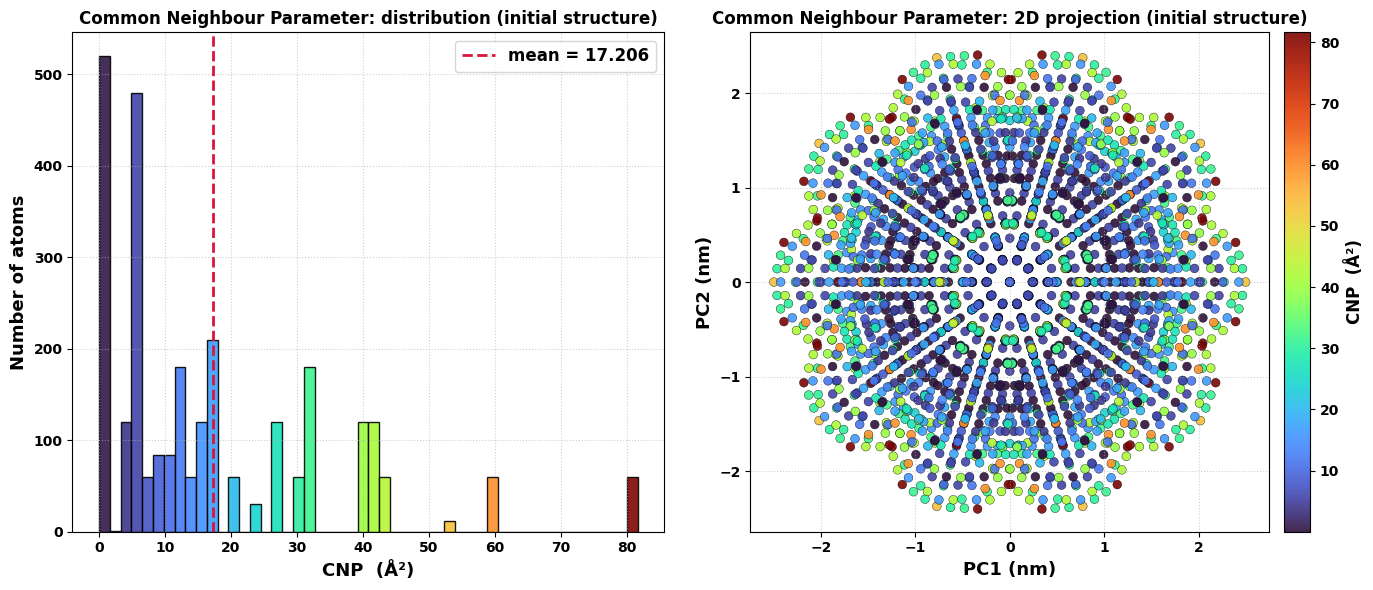

 - [ 0]        CNP (Å²)     0.02  →     120 atoms (  4.3 %)
 - [ 1]        CNP (Å²)     0.03  →      60 atoms (  2.1 %)
 - [ 2]        CNP (Å²)     0.04  →      20 atoms (  0.7 %)
 - [ 3]        CNP (Å²)     0.06  →      20 atoms (  0.7 %)
 - [ 4]        CNP (Å²)     0.07  →     120 atoms (  4.3 %)
 - [ 5]        CNP (Å²)     0.14  →     120 atoms (  4.3 %)
 - [ 6]        CNP (Å²)     0.20  →      60 atoms (  2.1 %)
 - [ 7]        CNP (Å²)     1.97  →       1 atoms (  0.0 %)
 - [ 8]        CNP (Å²)     4.24  →     120 atoms (  4.3 %)
 - [ 9]        CNP (Å²)     5.21  →      30 atoms (  1.1 %)
 - [10]        CNP (Å²)     5.23  →      60 atoms (  2.1 %)
 - [11]        CNP (Å²)     5.26  →      60 atoms (  2.1 %)
 - [12]        CNP (Å²)     5.31  →      30 atoms (  1.1 %)
 - [13]        CNP (Å²)     5.47  →     120 atoms (  4.3 %)
 - [14]        CNP (Å²)     5.52  →      60 atoms (  2.1 %)
 - [15]        CNP (Å²)     5.89  →      60 atoms (  2.1 %)
 - [16]        CNP (Å²)     5.96  →     

In [2]:
ico = pyNMB.from_file("coords/decorated_ico/ico_with_ino_opt.xyz", skipSymmetryAnalyzis=True, noOutput=True)
cnp = ico.common_neighbour_parameter(Xnn=2.95*1.3, noOutput=False)
ico.plot_local_order(descriptor='cnp')
ico.local_order_populations(descriptor="cnp", decimals=2, noOutput=False);
pyNMBu.write("coords/decorated_ico/ico_with_ino_opt_cnp.script", ico.jMol_cnp)

### A chiral dumbbell: two engraved partially chiral cubes clamping a twisted cobalt wire

#### Generation of the nano-object

<div class="intro">

This example assembles a more elaborate object that exercises several pyNMB capabilities at once: faceted carving, surface twisting, symmetry operations, multi-component assembly, and a bimetallic interface.

The target is a **chiral dumbbell**: two gold cubes, each engraved with an X shaped groove on one face, positioned so that their grooves clamp a hexagonal
cobalt nanowire from both ends. A same handed surface twist is applied to every component (both cubes and the wire), so the whole assembly is chiral.
Its chirality can then be quantified with the OPD index, which should come out non zero.

The construction proceeds in five steps:

1. **Engrave the cube.** A gold cube is carved with an X shaped groove on its
   top face, using `applySlicing` with two diagonal groove planes (`[1,1,0]`
   and `[-1,1,0]`, each replicated twofold) closed by a top cut that limits the
   groove depth to the upper half.

2. **Twist the two cubes with opposite handedness.** The engraved cube is
   duplicated. One copy is twisted right handed, the other left handed, using
   the per facet `applyTwist` with a `depth_nm` surface cap so that only the
   outer layer rotates while the core stays intact.

3. **Reflect one cube into place.** Reflecting the left handed cube through the
   z = 0 plane does two things at once: it flips its handedness back to right
   handed (a reflection inverts chirality) and it turns it upside down. The two
   cubes therefore end up same handed, with their engraved faces pointing
   toward each other.

4. **Build and twist the wire.** A hexagonal (sixfold) cobalt nanowire is grown
   along z, then given the same handed twist as the cubes.

5. **Assemble.** The two cubes and the wire are merged with `union_with` in
   `mode='atoms'`, which keeps both crystals and removes only directly
   overlapping atoms. This produces a clean, penetrating gold/cobalt interface
   where the engraved grooves grip the wire.

A gold only version is also produced at the end by copying the assembly and deleting the cobalt atoms with `delete(elements="Co")`,
which is convenient for inspecting the two cubes on their own.
</div>

In [2]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import crystalNPs  as cyNP

# ---------------------------------------------------------------------------
# 1. Gold cube
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Au cube A", size=18, weight="bold", bgc="#880002")
cubeA = pNP.cube(
    crystalStructure='fcc',
    element="Au",
    Rnn=2.9,
    size=5,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

# ---------------------------------------------------------------------------
# 2. Engrave an X groove on the top (+z) face
#    Two diagonal grooves ([1,1,0] and [-1,1,0]), each replicated at 180 deg,
#    form the X. The top cut limits the groove to the upper half of the cube.
# ---------------------------------------------------------------------------
planes = [
    # first diagonal groove
    {'normal': [ 1, 1, 0], 'distance': 7.0, 'nRot': 2, 'rotAxis': [0, 0, 1],
     'delete': 'above', 'modeP': 'OR'},
    # second diagonal groove, perpendicular to the first
    {'normal': [-1, 1, 0], 'distance': 7.0, 'nRot': 2, 'rotAxis': [0, 0, 1],
     'delete': 'above', 'modeP': 'OR'},
    # top cut: limits the depth of the X groove to the upper half
    {'normal': [ 0, 0, 1], 'distance': 0.0, 'nRot': 1,
     'delete': 'above', 'modeP': 'OR'},
]
cubeA.applySlicing(
    planes=planes,
    mode='AND',                  # remove an atom only if all groups condemn it
    distance_unit='Angstrom',
)
cubeA.applySlicing(
    planes=[{'normal': [ 0, 0, -1], 'distance': 5.0, 'nRot': 1, 'delete': 'above', 'modeP': 'OR'}],
    distance_unit='Angstrom',
    noOutput=False,
)

# duplicate the engraved cube before twisting (cubeB is the mirror partner)
pyNMBu.centertxt("Au cube B", size=18, weight="bold", bgc="#880002")
cubeB = cubeA.copy()

pyNMBu.write("coords/cubeX/cubeXA_Slices.script", cubeA.jMolSlices)
pyNMBu.write("coords/cubeX/cubXA.xyz", cubeA.NP)

# ---------------------------------------------------------------------------
# 3. Surface twist (upper 2.5 nm cap), opposite handedness on each cube.
#    cubeB is given LH here; the later reflection flips it back to RH, so both
#    cubes are same-handed in the final assembly (chiral dumbbell).
# ---------------------------------------------------------------------------
pyNMBu.centertxt("twist cube A", size=18, weight="bold", bgc="#880002")
cubeA.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.5, depth_nm=2.5,
                 noOutput=False)
pyNMBu.centertxt("twist cube B", size=18, weight="bold", bgc="#880002")
cubeB.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.5, depth_nm=2.5,
                 chirality="LH", noOutput=False)

pyNMBu.write("coords/cubeX/cubXA_twisted.xyz", cubeA.NP)
pyNMBu.write("coords/cubeX/cubXB_twisted.xyz", cubeB.NP)   # cubeB, not cubeA

# ---------------------------------------------------------------------------
# 4. Hexagonal cobalt (hcp) nanowire along z, then twist it (chiral wire)
# ---------------------------------------------------------------------------
pyNMBu.centertxt("Co wire", size=18, weight="bold", bgc="#880002")
direction = [0, 0, 1]
dim       = [1, 5]               # [section, length] per the Crystal wire API
refPlane  = [1, 0, 0]
nRot      = 6                    # hexagonal cross-section

wire = cyNP.Crystal(
    "Co hcp",
    shape='wire',
    size=dim,
    directionWire=direction,
    nRotWire=nRot,
    refPlaneWire=refPlane,
    pbc=False,
    aseView=False,
    skipSymmetryAnalyzis=True,
    skipFacetInfo=False,
    noOutput=True,
    threshold=3,
)
pyNMBu.write("coords/cubeX/CoWire.xyz", wire.NP)
pyNMBu.write("coords/cubeX/CoWire.script", wire.jMolCS)

wire.applyTwist(axis=[0, 0, 1], axis_def="cart", rate=0.8, noOutput=False)
pyNMBu.write("coords/cubeX/CoWire_twisted.xyz", wire.NP)
pyNMBu.write("coords/cubeX/CoWire_twisted.script", wire.jMolCS)

# ---------------------------------------------------------------------------
# 5. Position the two cubes and assemble
#    cubeA goes down (-z), cubeB is reflected (handedness flip + upside down)
#    then moved up (+z) so the two engraved faces clamp the wire from both
#    sides. union_with(..., mode='atoms') keeps both crystals and only removes
#    directly overlapping atoms, giving a clean penetrating Au/Co interface.
# ---------------------------------------------------------------------------
pyNMBu.centertxt("cubes A & B: translation and reflection", size=18, weight="bold", bgc="#880002")
cubeA.apply_translation([0, 0, -6.5], vector_def='cart')
cubeB.apply_reflection(plane=[0, 0, 1, 0], plane_def='cart', noOutput=True)
cubeB.apply_translation([0, 0,  -6.5], vector_def='cart')

pyNMBu.centertxt("cube A union cube B", size=18, weight="bold", bgc="#880002")
cubeA.union_with(cubeB, mode='hull', threshold=0.8, recenter=True, noOutput=False)
pyNMBu.write("coords/cubeX/CC.xyz", cubeA.NP)            # the two cubes alone

pyNMBu.centertxt("cube A+cube B union wire", size=18, weight="bold", bgc="#880002")
cubeA.union_with(wire, mode='hull', threshold=0.8, recenter=True, noOutput=False)
pyNMBu.write("coords/cubeX/dumbbell_CoWire.xyz", cubeA.NP)
print(f"Done. Total atoms = {cubeA.nAtoms}")

# ---------------------------------------------------------------------------
# 6. Gold-only version: drop the cobalt wire (e.g. to image the cubes alone)
# ---------------------------------------------------------------------------
pyNMBu.centertxt("cube A+cube B saved", size=18, weight="bold", bgc="#880002")
AuCubes = cubeA.copy()
AuCubes.delete(elements="Co")
pyNMBu.write("coords/cubeX/dumbbell_CoWire_woCo.xyz", AuCubes.NP)

# ---------------------------------------------------------------------------
# 7. Geometry optimization of the dumbbell
# ---------------------------------------------------------------------------
pyNMBu.centertxt("geometry optimization", size=18, weight="bold", bgc="#880002")
cubeA.optimize(calculator="eam", eam_potential="./coords/cubeX/CuAgAuNiPdPtAlPbFeMoTaWMgCoTiZr_Zhou04.eam.alloy", noOutput=False,
               xyz_file="./coords/cubeX/dumbbell_CoWire_opt_tmp.xyz", fthreshold=0.15)
pyNMBu.write("coords/cubeX/dumbbell_CoWire_opt.xyz", cubeA.NP_opt)


  Group 1 — normal: [0, 0, -1]  nRot: 1  distance: 5.0 Angstrom  side to delete: above  modeP: OR
    [+0.0000 +0.0000 -1.0000]  d = 5.000 Å
  2500 atoms removed, 3777 remaining.


Moments of inertia = 238541609.12 238541609.12 317396514.67 amu.Å2
Moments of inertia / M = 320.65 320.65 426.64 amu.Å2
Moments of inertia with mass=1/M = 320.65 320.65 426.64 Å2


 Principal Moments : I1=320.65, I2=320.65, I3=426.64
 NPR1 (I1/I3)      : 0.7516
 NPR2 (I2/I3)      : 0.7516
 Predicted Shape   : Spherical/Symmetric


 Rg = 2.3 nm


Found:
  - 8 vertices
  - 12 simplices
  - Volume: 79.47 nm³
  - Area: 113.03 nm²
Duration : 00:00:00 002ms


...

 Rg = 3.9 nm


Found:
  - 274 vertices
  - 544 simplices
  - Volume: 222.67 nm³
  - Area: 218.48 nm²
Duration : 00:00:00 006ms


1306 atoms lie in the plane(s)
Duration : 00:00:00 025ms


Diameter of the circumscribed sphere: 112.69 Å
Diameter of the inscribed sphere: 50.51 Å


  - Dimensions (Å): 113.94 x 50.91 x 54.41
  - Volume: 165.26 nm³
  - Surface: 159.34 nm²
  - Asphericity: 2.09
  - Max Radius found: 5.697 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {-0.000001 -0.373886 56.970602} {-0.000014 25.456134 0.167063} {27.203633 0.000015 0.000000}; ellipsoid ID optimized_structure_el CENTER {-1.443 -0.000 0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 23:37:56 132ms


#### Post-processing: local order descriptors

 - Source              : initial structure
 - Cutoff Xnn          : 3.835 Å
 - Mean CNP <Q>        : 19.645 Å²
 - CNP range           : 0.000 – 121.161 Å²
 - Stored as           : self.cnp  (per atom), self.cnp_mean  (scalar)
Duration : 00:00:00 062ms


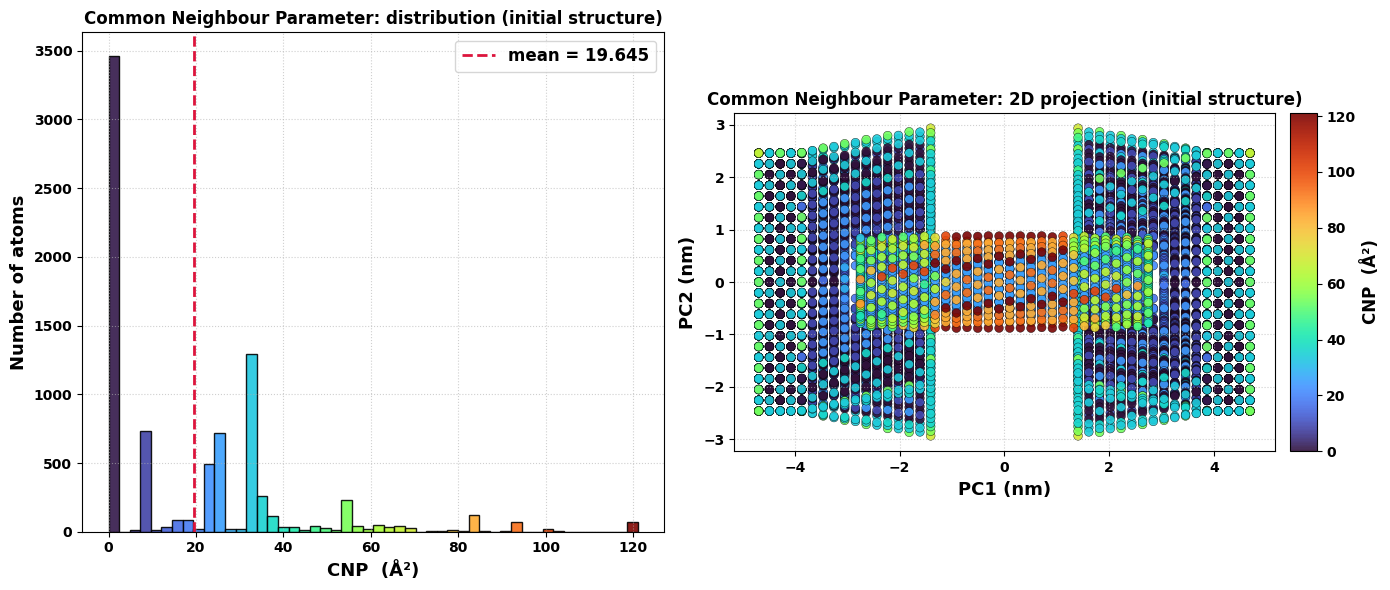

 - [ 0]        CNP (Å²)     0.00  →    1122 atoms ( 13.5 %)
 - [ 1]        CNP (Å²)     0.01  →    1746 atoms ( 21.0 %)
 - [ 2]        CNP (Å²)     0.02  →     128 atoms (  1.5 %)
 - [ 3]        CNP (Å²)     0.03  →     128 atoms (  1.5 %)
 - [ 4]        CNP (Å²)     0.04  →      64 atoms (  0.8 %)
 - [ 5]        CNP (Å²)     0.05  →      40 atoms (  0.5 %)
 - [ 6]        CNP (Å²)     0.06  →      32 atoms (  0.4 %)
 - [ 7]        CNP (Å²)     0.09  →       8 atoms (  0.1 %)
 - [ 8]        CNP (Å²)     0.10  →      16 atoms (  0.2 %)
 - [ 9]        CNP (Å²)     0.16  →       8 atoms (  0.1 %)
 - [10]        CNP (Å²)     0.17  →      16 atoms (  0.2 %)
 - [11]        CNP (Å²)     0.24  →       8 atoms (  0.1 %)
 - [12]        CNP (Å²)     0.25  →      16 atoms (  0.2 %)
 - [13]        CNP (Å²)     0.35  →       8 atoms (  0.1 %)
 - [14]        CNP (Å²)     0.36  →      16 atoms (  0.2 %)
 - [15]        CNP (Å²)     0.47  →       8 atoms (  0.1 %)
 - [16]        CNP (Å²)     0.48  →     

In [3]:
db = pyNMB.from_file("coords/cubeX/dumbbell_CoWire.xyz", skipSymmetryAnalyzis=True, noOutput=True)
cnp = db.common_neighbour_parameter(Xnn=2.95*1.3, noOutput=False)
db.plot_local_order(descriptor='cnp')
db.local_order_populations(descriptor="cnp", decimals=2, noOutput=False);
pyNMBu.write("coords/cubeX/dumbbell_CoWire_cnp.script", db.jMol_cnp)

### Comparison of the (q4,q6) maps

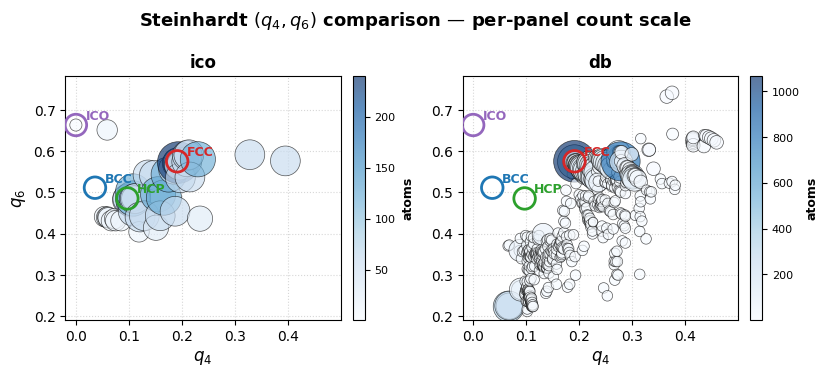

In [5]:
for o, rnn in [(ico, 2.884), (db, 2.884)]:
    o.steinhardt_q(Xnn=rnn*1.3, l=4)
    o.steinhardt_q(Xnn=rnn*1.3, l=6)
pyNMBu.compare_q4q6_map([ico, db], labels=['ico', 'db'], ncols=2, nrows=1)

In [4]:
pyNMB.end()

**End at:** Tuesday 09 June 2026, 17:48:08  
**Duration:** 00:00:11 663ms

# End